In [1]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn
import scipy
import writing
import analysis

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


None
..\..\corpus\metro_sample_1\input.wav
True


Analysis of grains using AudioFlux

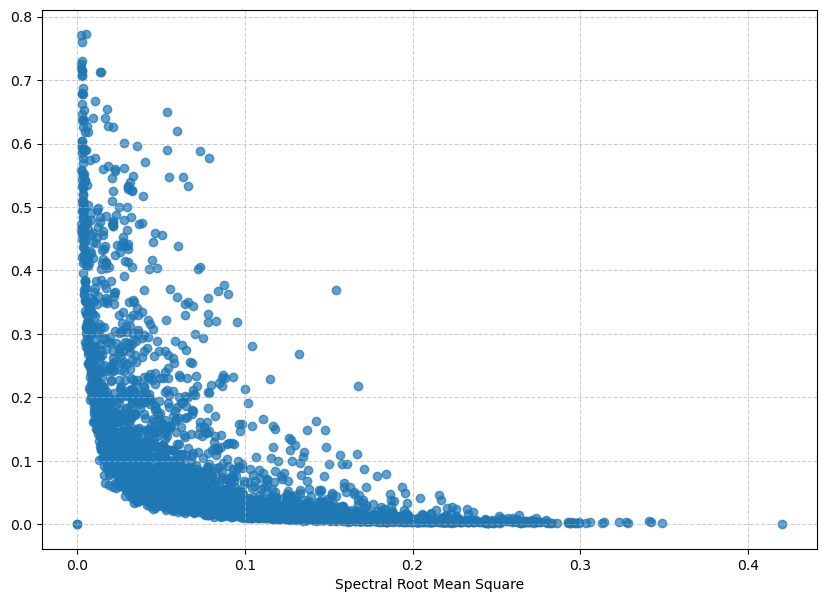

In [7]:
input_file = "..\..\corpus\\guitar_sample_2\input.wav"
output_dir = "..\..\corpus\\guitar_sample_2"

sr=48000
grain_duration = 0.1 # in s

y, sr = af.read(input_file, samplate=sr) # sr is 48kHz

grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
flatness_arr = spectral_obj.flatness(spec_arr)
plt.figure(figsize=(10, 7))
plt.scatter(flatness_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Analysis of grains using Librosa
TODO:
1. Why 2048 window for the analysis, and, why 512 hop length, define this in the methodology. 
2. Elaborate on method for assigning descriptor values to grains
3. Chosen descriptors are hierarchically different according to Peeters graphic. 
4. Audio is loaded in mono, so no need to account for more than one channel in the analysis

In [14]:
from librosa import feature

In [ ]:
import os
PATH = "..\..\corpus\\guitar_sample_2"


class Analyzer():
    def __init__(self, path, sr):
        self.path = path
        self.sr=sr
        self.input_path = os.path.normpath(path + "\\input.wav")
        self.y = None
        self.stft = None
        self.loaded_y=False
        self.loaded_stft=False

    def compute_stft(self,
        n_fft: int = 2048,
        hop_length: int = 512,
        win_length = None,
        window = "hann",
        center: bool = True,
        pad_mode = "constant",
        ):
        if not self.loaded_y:
            self.load_audio_data()
            self.loaded_y=True
        stft = librosa.stft(
            y=self.y,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window,
            center=center,
            pad_mode=pad_mode,
        )
        self.stft = np.abs(stft)

    
    def load_audio_data(self):
        y, _ = af.read(path=self.input_path, samplate=self.sr)
        self.y = y
    
    def compute_zrc(self, n_fft=2048, hop_length=512):
        """ 
        Compute ZRC.
        """
        if not self.loaded_stft:
            self.compute_stft()
            self.loaded_stft=True
        arr = librosa.feature.zero_crossing_rate(S=self.stft, n_fft=n_fft, hop_length=hop_length)
        return arr 

    def compute_flatness(self, n_fft=2048, hop_length=512):
        """ 
        Compute spectral Flatness, standard Hanning window. 
        """
        if not self.loaded_stft:
            self.compute_stft()
            self.loaded_stft=True
        arr = librosa.feature.spectral_flatness(S=self.stft, n_fft=n_fft, hop_length=hop_length)
        return arr
    
    def compute_rms(self, n_fft=2048, hop_length=512):
        """ 
        We use the Audio data 
        """
        if not self.loaded_stft:
            self.compute_stft()
            self.loaded_stft=True
        arr = librosa.feature.rms(S=self.stft, n_fft=n_fft, hop_length=hop_length)
        return arr
    
    def compute_centroid(self, n_fft=2048, hop_length=512):
        """ 
        We use the Audio data 
        """
        if not self.loaded_stft:
            self.compute_stft()
            self.loaded_stft=True
        arr = librosa.feature.spectral_centroid(S=self.stft, n_fft=n_fft, hop_length=hop_length)
        return arr
    
    def compute_rolloff(self, n_fft=2048, hop_length=512):
        """ 
        We use the Audio data 
        """
        if not self.loaded_stft:
            self.compute_stft()
            self.loaded_stft=True
        arr = librosa.feature.spectral_rolloff(S=self.stft, n_fft=n_fft, hop_length=hop_length)
        return arr
    
    def convert_descriptor_arr(self, arr, grain_duration):
        """ 
        Grain duration in seconds. 
        Convert the descriptor arr to have descr values for each sample, can then compute per grain
        descr value. 
        """
        grain_size = int(self.sr*grain_duration)
        if self.loaded_y:
            incr = self.y.shape[-1]//arr.shape[-1]
            buffer = np.array([])
            index = 0
            for i in range(self.y.shape[-1]):
                if i 

            while buffer.shape[-1] < self.y.shape[-1]:
                buffer = np.concatenate(buffer, np.array([arr[index] for i in range(incr)])) 
                index+=1 
            return buffer              


In [57]:
analyzer = Analyzer(PATH, sr)
analyzer.compute_stft()
rolloff_arr = analyzer.compute_rolloff()
# centroid_arr = analyzer.compute_centroid()
analyzer

In [ ]:
analyzer.input_path


In [58]:

analyzer.convert_descriptor_arr(rolloff_arr, 0.1)

TypeError: only integer scalar arrays can be converted to a scalar index